# benrfv3

Workbook-filtered grouped-variable RF/ElasticNet pipeline with an initial RF feature-screening stage and a 90% cumulative-importance cutoff.


LOAD DATA
Raw dataset shape: (244097, 120)
Filtered dataset shape (age 13.0-16.5): (156603, 120)

BUILD DISTRESS TARGET
Rows after dropping missing target items: 150867
Percent removed: 3.66 %
Cronbach's alpha for distress items: 0.7366
count    150867.000000
mean         32.551572
std          21.851741
min           0.000000
25%          15.507228
50%          28.447825
75%          47.538604
max         100.000000
Name: distress_score_100, dtype: float64


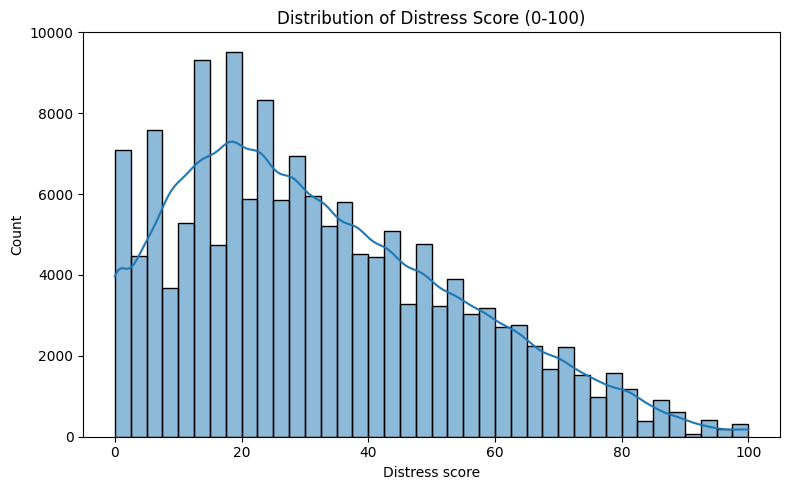

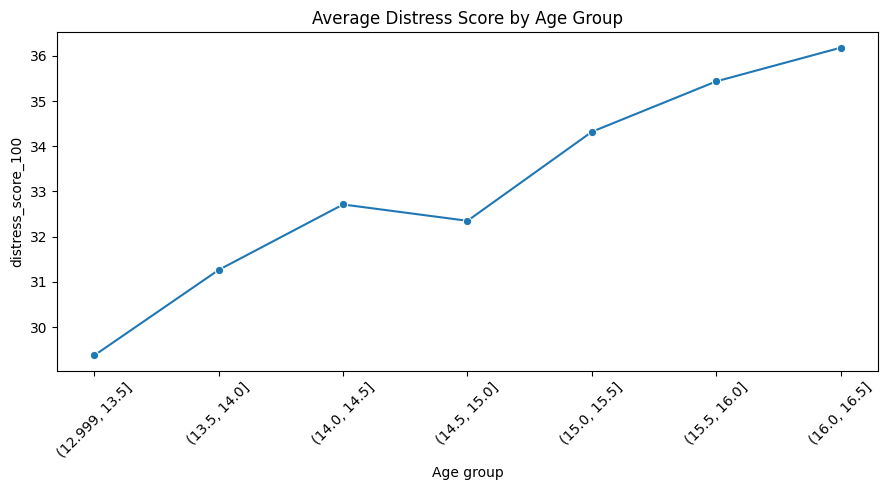


BUILD FEATURES FROM WORKBOOK
Workbook rows kept for modelling: 72
Engineered feature count: 56

Feature manifest:
           feature feature_type                            source_cols      new_group                             aggregation_method long_term_var                                                                                                                   new_question missing_source_cols
               age   standalone                                    age                                                           raw             Y                                                                                                                                                   
               sex   standalone                                    sex                                                           raw             Y                                                                                                                                                   
   

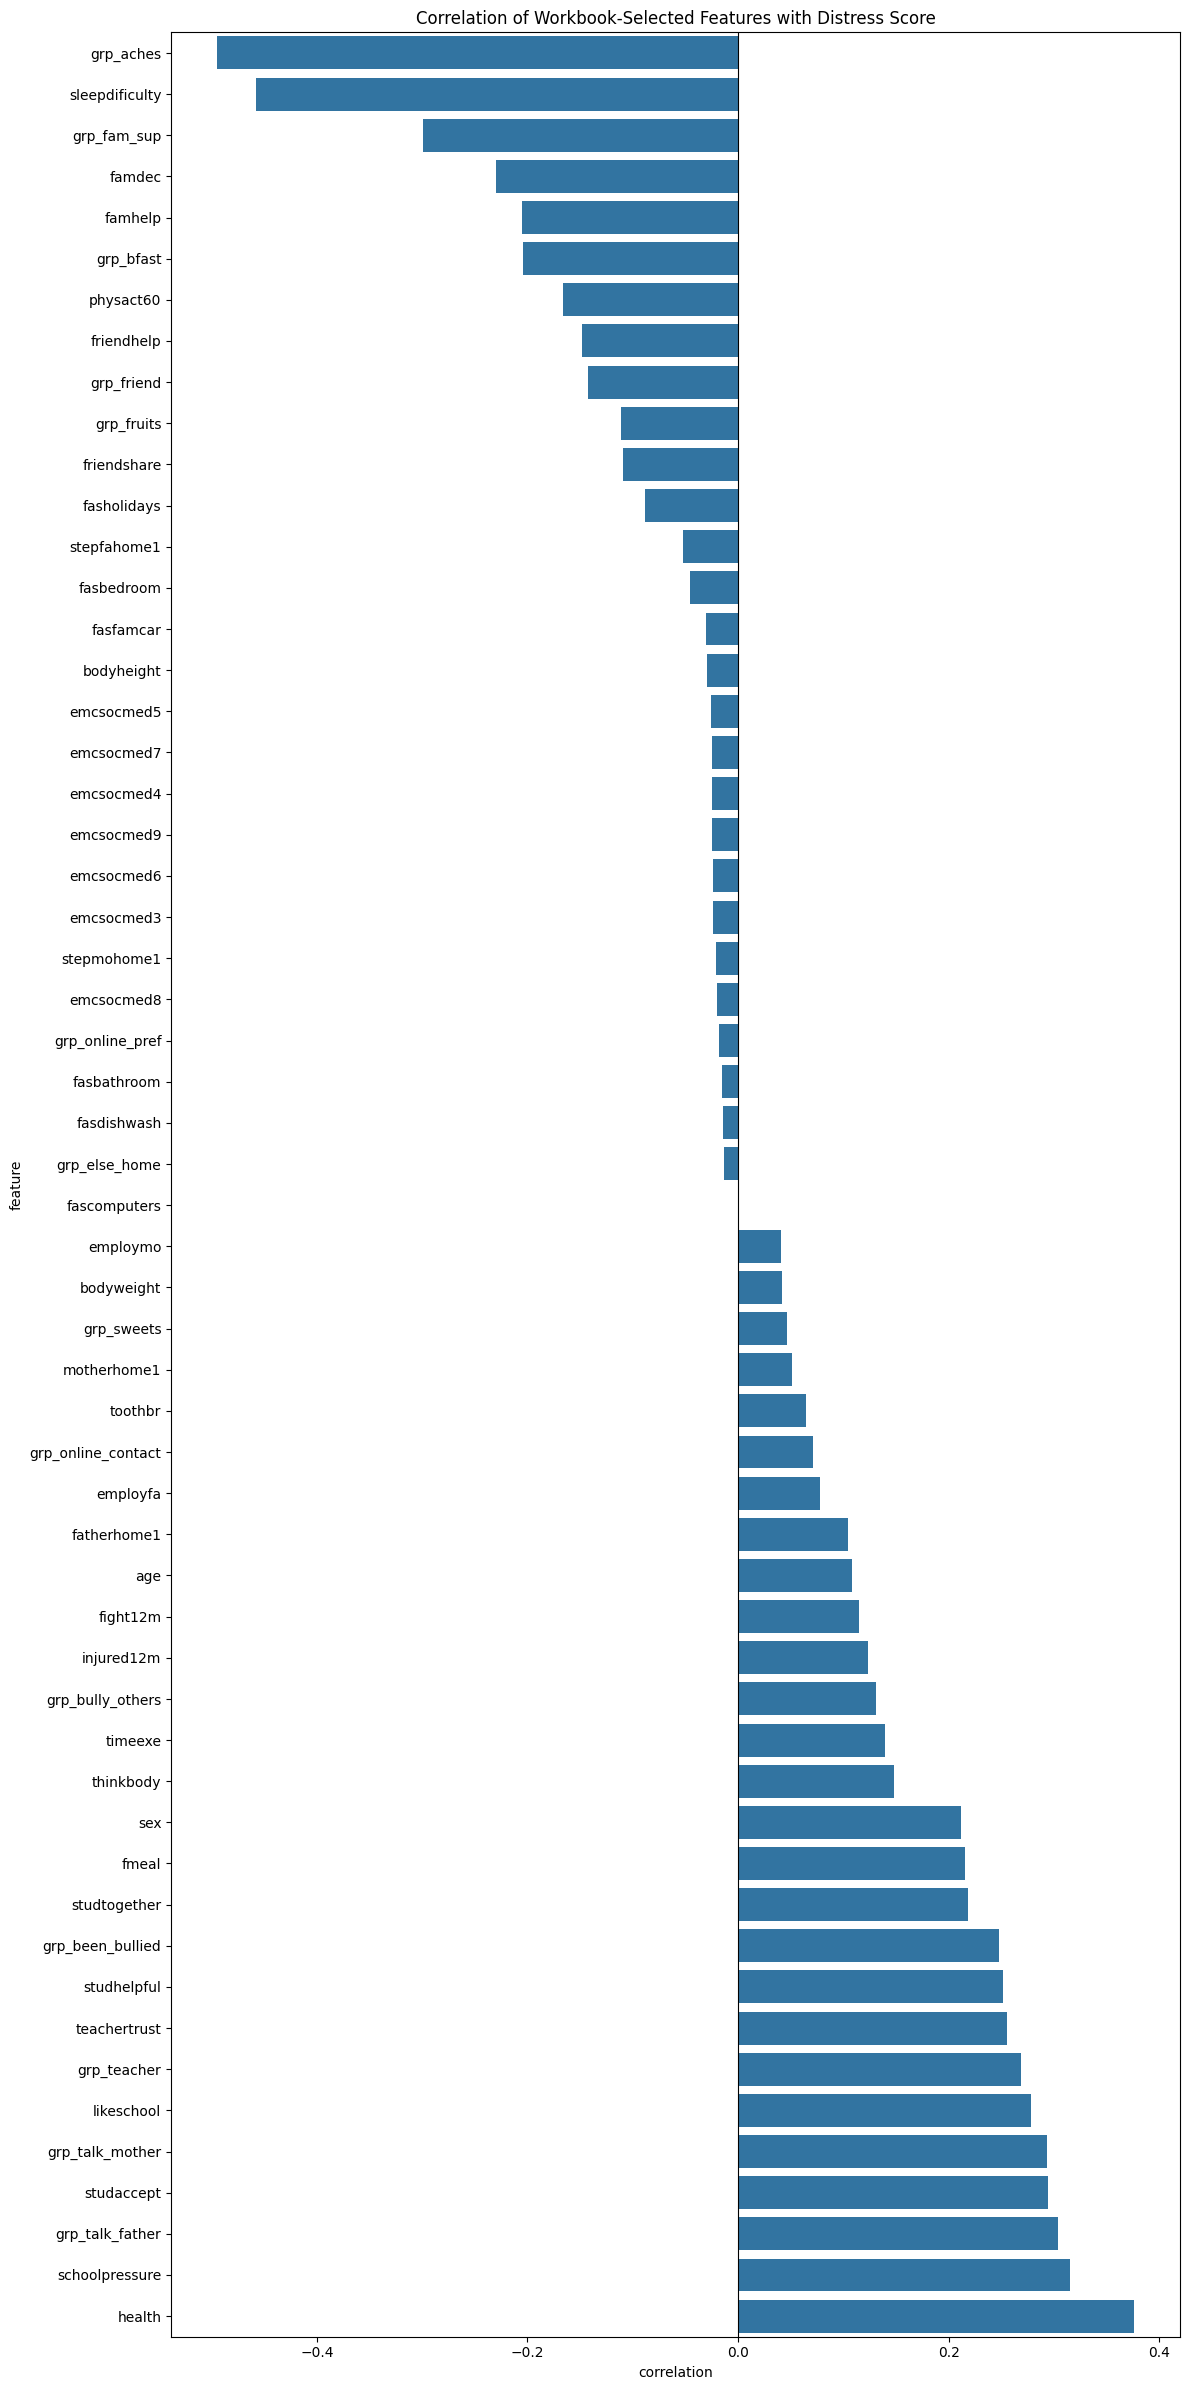


DEFINE MODELS
ElasticNet pipeline ready.
Random Forest pipeline ready.

HYPERPARAMETER TUNING
X_all shape before modelling: (150867, 56)
Reusing the original benrf.ipynb tuned RF hyperparameters to keep the screening run tractable on the workbook-selected feature set.
Using RF params:
  n_estimators: 800
  min_samples_split: 5
  min_samples_leaf: 5
  max_features: 0.5
  max_depth: None
  n_jobs: -1
  random_state: 42

Tuned RF pipeline ready.

PRELIMINARY FEATURE IMPORTANCE RUN

--- RandomForest ---
  Run 1: train_r2=0.7855, test_r2=0.5020, test_rmse=15.45
  Run 2: train_r2=0.7864, test_r2=0.4914, test_rmse=15.57
  Run 3: train_r2=0.7851, test_r2=0.5063, test_rmse=15.38
  Run 4: train_r2=0.7842, test_r2=0.5127, test_rmse=15.30
  Run 5: train_r2=0.7863, test_r2=0.4946, test_rmse=15.48

Screening feature importance summary:
           feature  mean_importance  std_importance  importance_share  cumulative_importance  selected_for_modelling
         grp_aches         0.213173        0.001

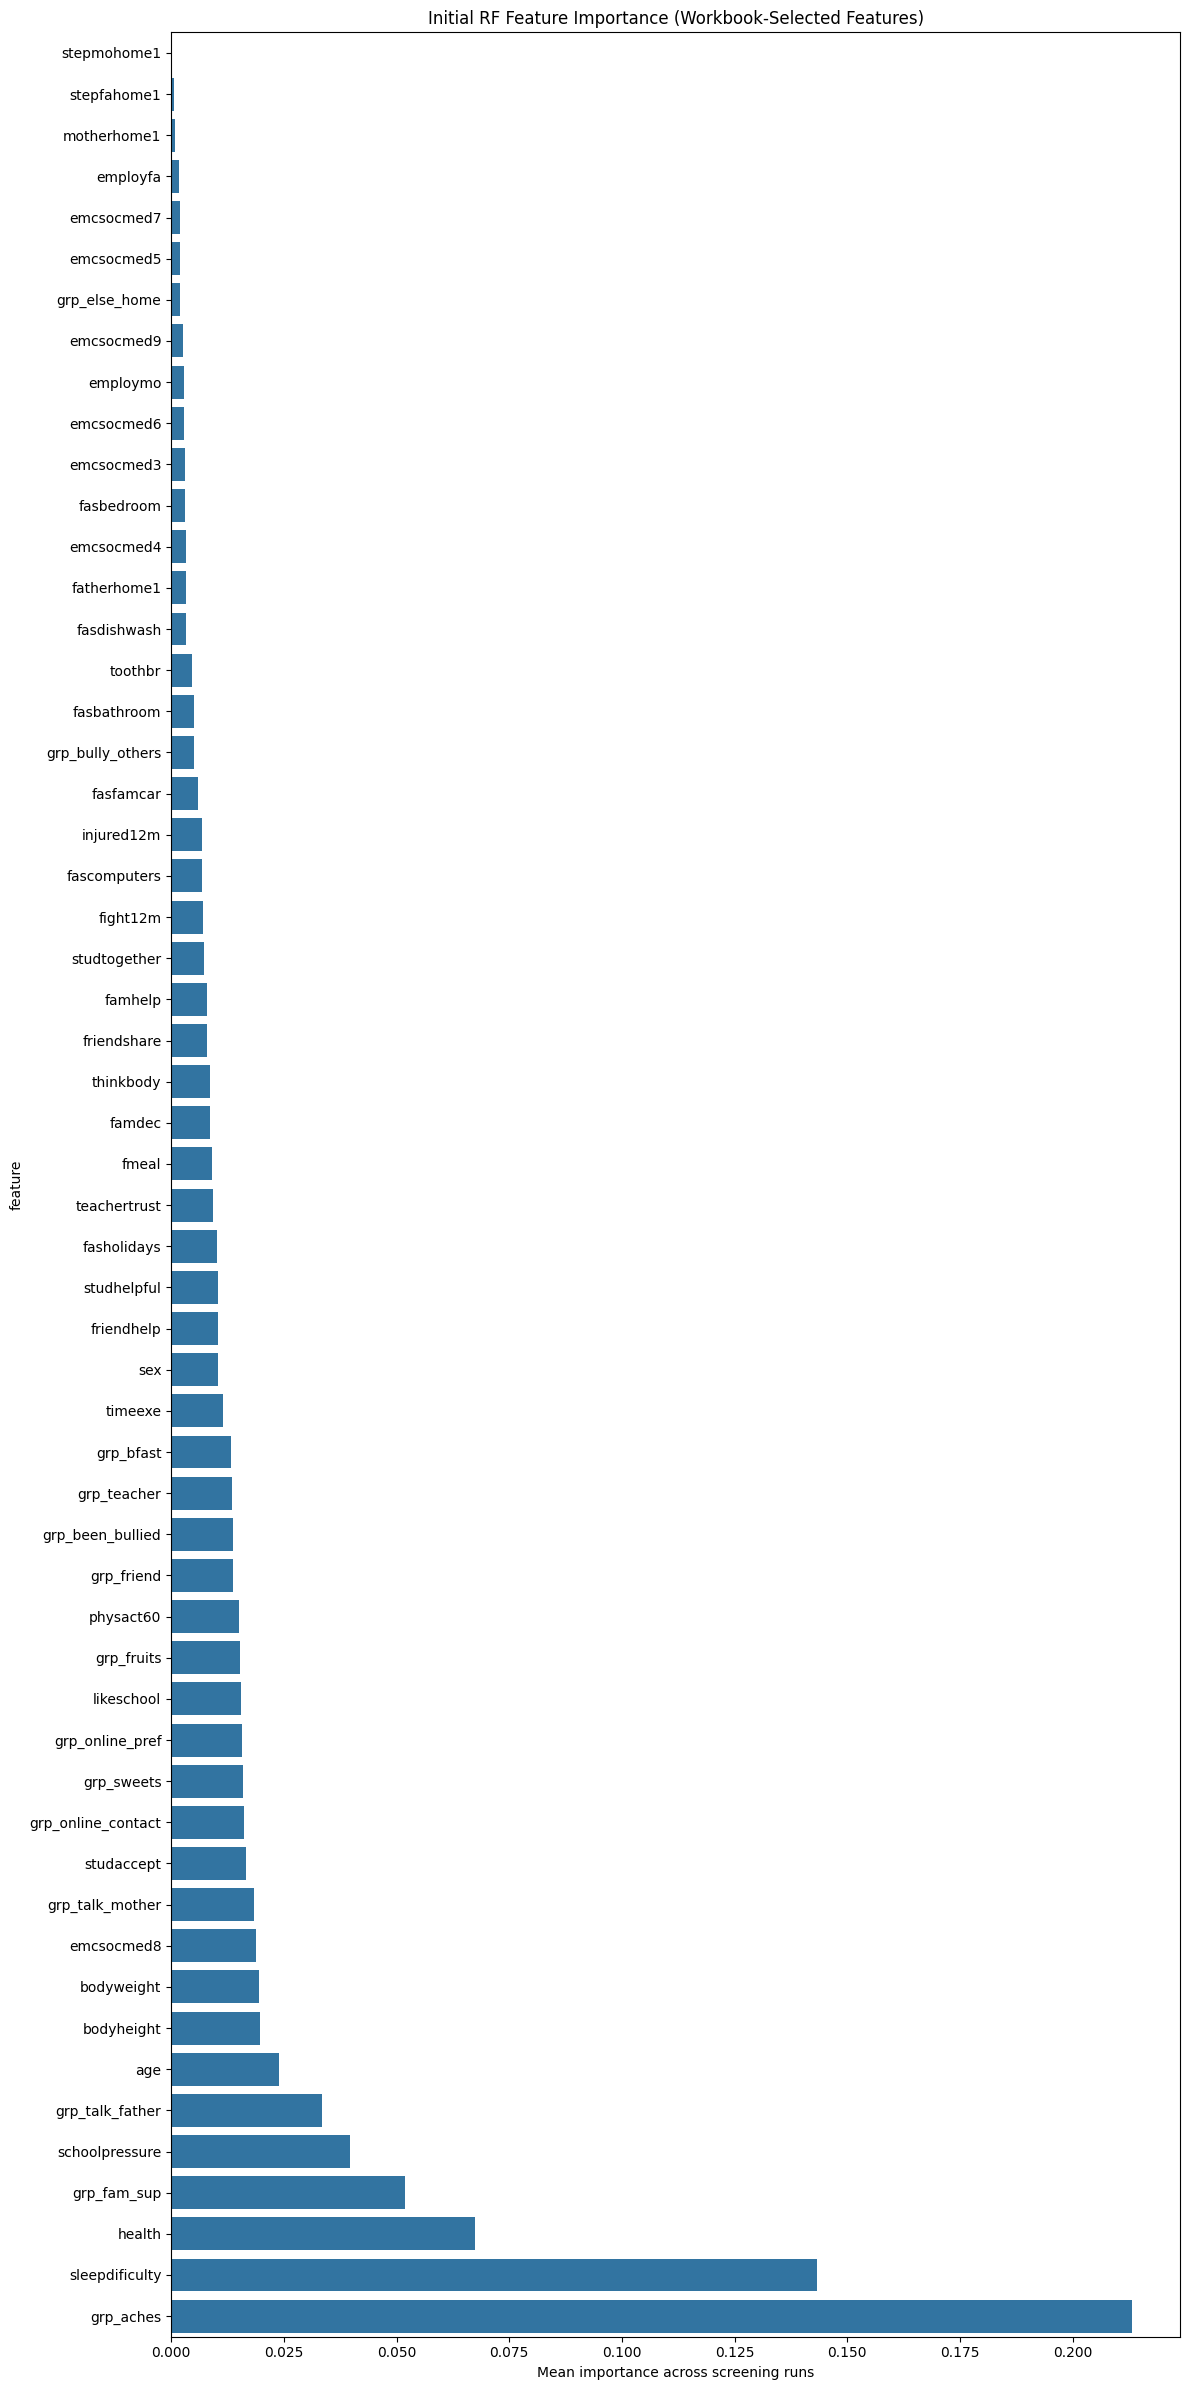


REPEATED OOS VALIDATIONS

--- ElasticNet ---
  Run 1: train_r2=0.4810, test_r2=0.4791, test_rmse=15.80
  Run 2: train_r2=0.4830, test_r2=0.4711, test_rmse=15.88
  Run 3: train_r2=0.4799, test_r2=0.4834, test_rmse=15.73
  Run 4: train_r2=0.4775, test_r2=0.4927, test_rmse=15.61
  Run 5: train_r2=0.4822, test_r2=0.4742, test_rmse=15.79

--- RandomForest ---
  Run 1: train_r2=0.7706, test_r2=0.4980, test_rmse=15.51
  Run 2: train_r2=0.7716, test_r2=0.4879, test_rmse=15.63
  Run 3: train_r2=0.7701, test_r2=0.5029, test_rmse=15.43
  Run 4: train_r2=0.7691, test_r2=0.5093, test_rmse=15.35
  Run 5: train_r2=0.7713, test_r2=0.4904, test_rmse=15.54

MODEL COMPARISON
              mean_test_r2  std_test_r2  mean_test_rmse  std_test_rmse  mean_test_mae  std_test_mae  mean_train_r2
model                                                                                                             
ElasticNet          0.4801       0.0085         15.7602         0.1008        12.4201        0.0639     

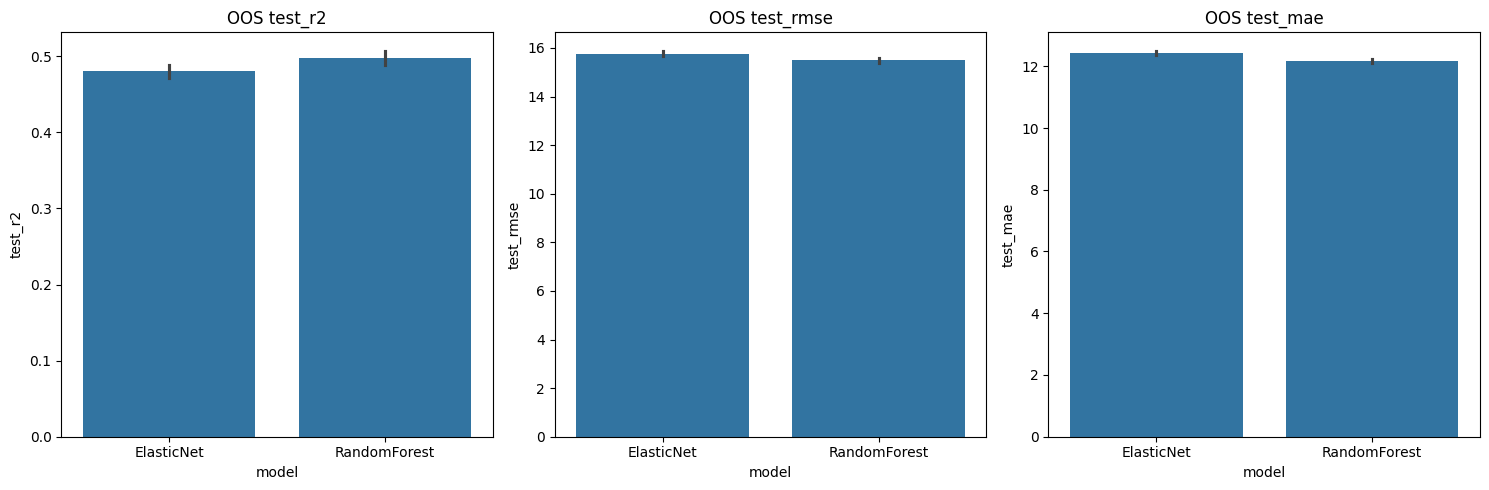


FEATURE IMPORTANCE
           feature  mean_importance  std_importance
         grp_aches         0.220979        0.001569
    sleepdificulty         0.145105        0.001167
            health         0.066766        0.001169
       grp_fam_sup         0.057607        0.001315
    schoolpressure         0.041393        0.000497
   grp_talk_father         0.037616        0.001893
               age         0.029406        0.000163
        bodyheight         0.024694        0.000177
        bodyweight         0.024558        0.000233
        emcsocmed8         0.020560        0.000815
grp_online_contact         0.020500        0.000199
        grp_sweets         0.020045        0.000188
   grp_talk_mother         0.020023        0.000557
   grp_online_pref         0.019936        0.000202
        grp_fruits         0.019327        0.000095
        studaccept         0.018862        0.000442
        grp_friend         0.018523        0.000183
         physact60         0.018464        0

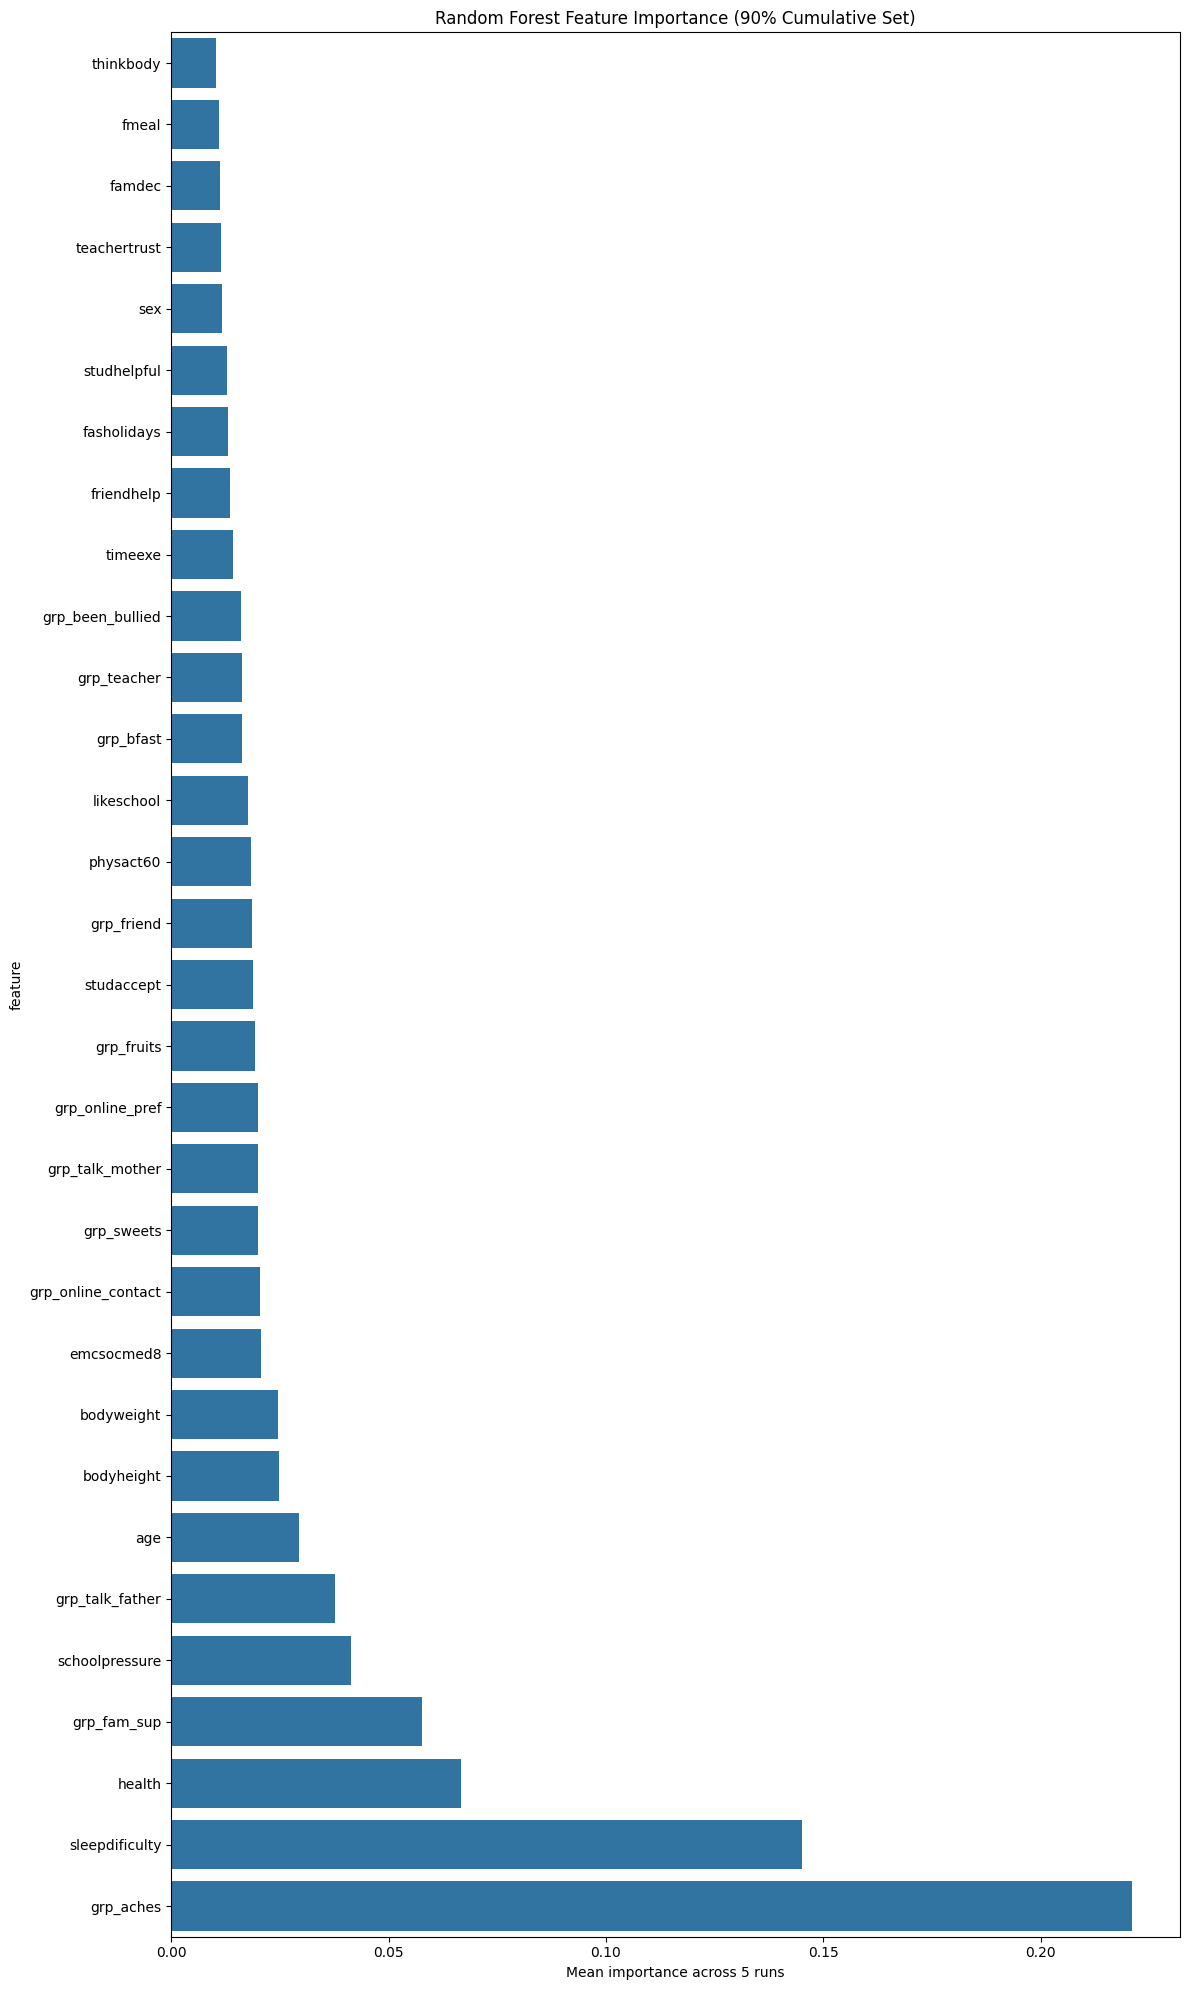


FINAL MODEL ON FULL SAMPLE
In-sample R2: 0.7709
Mean OOS R2:  0.4977
Overfit gap:  0.2732


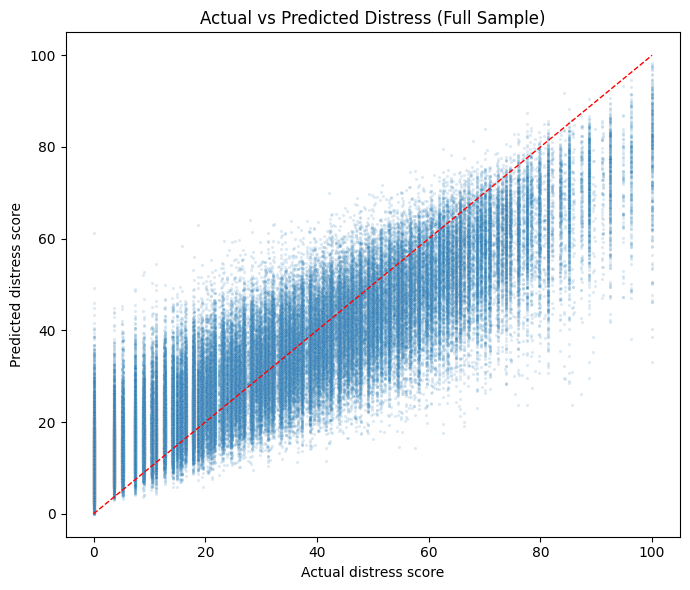

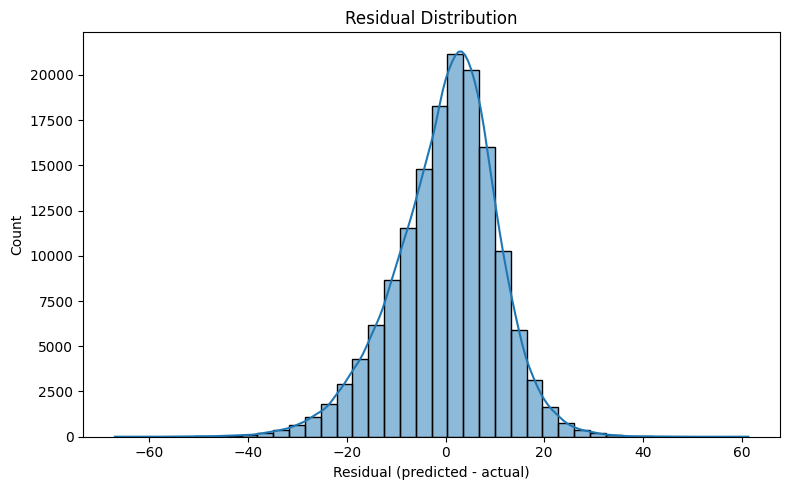

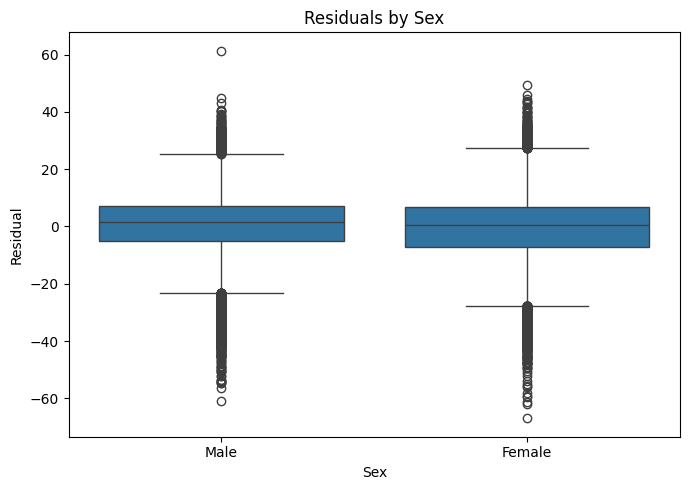


SAVE OUTPUTS
Saved:
 - benrfv3_feature_screening.csv
 - benrfv3_oos_results.csv
 - benrfv3_vs_elasticnet_comparison.csv
 - benrfv3_feature_importance.csv
 - benrfv3_final_predictions.csv
 - benrfv3_feature_manifest.csv
 - benrfv3_selected_feature_manifest.csv

SUMMARY
Initial feature count:  56
Selected feature count: 31

Random Forest
  Mean OOS R2:   0.4977 +/- 0.0088
  Mean OOS RMSE: 15.49 +/- 0.11
  Mean OOS MAE:  12.18 +/- 0.07

ElasticNet
  Mean OOS R2:   0.4801 +/- 0.0085
  Mean OOS RMSE: 15.76 +/- 0.10
  Mean OOS MAE:  12.42 +/- 0.06

R2:   0.4801 -> 0.4977 (+0.0176)
RMSE: 15.76 -> 15.49 (-0.27)

All features by importance:
           feature  mean_importance  std_importance
         grp_aches         0.220979        0.001569
    sleepdificulty         0.145105        0.001167
            health         0.066766        0.001169
       grp_fam_sup         0.057607        0.001315
    schoolpressure         0.041393        0.000497
   grp_talk_father         0.037616        0.00

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


DATA_PATH = "HBSC_data/HBSC2018OAed1.1.csv"
GROUPINGS_PATH = "HBSC_data/hbsc_variable_groupings.xlsx"
OUTPUT_PREFIX = "benrfv3"
AGE_MIN = 13.0
AGE_MAX = 16.5
TARGET = "distress_score_100"
N_OOS_RUNS = 5
TEST_SIZE = 0.20
RANDOM_SEEDS = [11, 23, 37, 49, 61]
MIN_STRATUM_COUNT = 30
IMPORTANCE_COVERAGE = 0.90


def cronbach_alpha(df_items):
    items = df_items.dropna().copy()
    k = items.shape[1]
    if k <= 1:
        return np.nan
    item_variances = items.var(axis=0, ddof=1)
    total_variance = items.sum(axis=1).var(ddof=1)
    if total_variance == 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_variances.sum() / total_variance)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def print_header(title):
    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))


def clean_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip().strip("'").strip()


def slugify_group(name):
    slug = re.sub(r"[^0-9a-zA-Z]+", "_", clean_text(name).lower()).strip("_")
    return slug or "unnamed"


def first_nonempty(values, default=""):
    for value in values:
        value = clean_text(value)
        if value:
            return value
    return default


def load_feature_plan(path):
    plan = pd.read_excel(path).iloc[:, :6].copy()
    plan.columns = [
        "hbsc_var",
        "new_group",
        "aggregation_method",
        "new_question",
        "omit_for_modelling",
        "long_term_var",
    ]
    for col in plan.columns:
        plan[col] = plan[col].map(clean_text)
    plan = plan[plan["hbsc_var"] != ""].reset_index(drop=True)
    return plan


def aggregate_feature(df_source, source_cols, method):
    numeric = pd.DataFrame(index=df_source.index)
    for col in source_cols:
        if col in df_source.columns:
            numeric[col] = pd.to_numeric(df_source[col], errors="coerce")
        else:
            numeric[col] = np.nan

    if method == "mean":
        return numeric.mean(axis=1, skipna=True)

    if method == "sum - 2":
        counts = numeric.notna().sum(axis=1)
        summed = numeric.sum(axis=1, min_count=1) - counts
        summed[counts == 0] = np.nan
        return summed

    if method == "take the most frequent":
        return numeric.max(axis=1, skipna=True)

    if method == "take the most frequent out of all the symptoms":
        return numeric.min(axis=1, skipna=True)

    if method == "at least 1 yes = new yes":
        any_nonmissing = numeric.notna().any(axis=1)
        any_yes = numeric.eq(1).any(axis=1)
        out = pd.Series(np.nan, index=numeric.index, dtype=float)
        out[any_nonmissing] = 2.0
        out[any_yes] = 1.0
        return out

    if not method and len(source_cols) == 1:
        return numeric.iloc[:, 0]

    raise ValueError(f"Unsupported aggregation method: {method!r} for {source_cols}")


def build_feature_matrix(df_source, feature_plan):
    keep_plan = feature_plan[feature_plan["omit_for_modelling"] == "N"].copy()

    feature_data = {}
    manifest_rows = []
    seen = set()

    for _, row in keep_plan.iterrows():
        raw_col = row["hbsc_var"]
        group_name = row["new_group"]

        if group_name:
            feature_name = f"grp_{slugify_group(group_name)}"
            if feature_name in seen:
                continue

            group_rows = keep_plan[keep_plan["new_group"] == group_name].copy()
            source_cols = group_rows["hbsc_var"].tolist()
            method = first_nonempty(group_rows["aggregation_method"], default="raw")
            question = first_nonempty(group_rows["new_question"])
            long_term = "Y" if (group_rows["long_term_var"] == "Y").any() else "N"
            missing_cols = [c for c in source_cols if c not in df_source.columns]

            feature_data[feature_name] = aggregate_feature(
                df_source,
                source_cols,
                first_nonempty(group_rows["aggregation_method"]),
            )
            manifest_rows.append({
                "feature": feature_name,
                "feature_type": "grouped",
                "source_cols": ", ".join(source_cols),
                "new_group": group_name,
                "aggregation_method": method,
                "long_term_var": long_term,
                "new_question": question,
                "missing_source_cols": ", ".join(missing_cols),
            })
            seen.add(feature_name)
            continue

        if raw_col in seen:
            continue

        if raw_col in df_source.columns:
            feature_series = pd.to_numeric(df_source[raw_col], errors="coerce")
            missing_cols = []
        else:
            feature_series = pd.Series(np.nan, index=df_source.index, dtype=float)
            missing_cols = [raw_col]

        feature_data[raw_col] = feature_series
        manifest_rows.append({
            "feature": raw_col,
            "feature_type": "standalone",
            "source_cols": raw_col,
            "new_group": "",
            "aggregation_method": "raw",
            "long_term_var": row["long_term_var"] or "N",
            "new_question": row["new_question"],
            "missing_source_cols": ", ".join(missing_cols),
        })
        seen.add(raw_col)

    feature_df = pd.DataFrame(feature_data, index=df_source.index)
    feature_cols = list(feature_df.columns)
    manifest_df = pd.DataFrame(manifest_rows)
    return feature_df, feature_cols, manifest_df


def build_model_inputs(working_df, feature_names):
    X_data = working_df[feature_names].copy()
    y_data = working_df[TARGET].copy()
    strata_data = working_df["strata"].copy()

    for col in X_data.columns:
        X_data[col] = pd.to_numeric(X_data[col], errors="coerce")

    drop_cols = X_data.columns[X_data.isnull().mean() > 0.95].tolist()
    if drop_cols:
        X_data = X_data.drop(columns=drop_cols)
        feature_names = [c for c in feature_names if c not in drop_cols]

    return X_data, y_data, strata_data, feature_names, drop_cols


def run_repeated_oos(models, X_data, y_data, strata_data, feature_names):
    all_oos_results = []
    rf_importances = []

    for model_name, base_model in models.items():
        print(f"\n--- {model_name} ---")
        for run_id, seed in enumerate(RANDOM_SEEDS[:N_OOS_RUNS], start=1):
            X_train, X_test, y_train, y_test, _, _ = train_test_split(
                X_data,
                y_data,
                strata_data,
                test_size=TEST_SIZE,
                random_state=seed,
                stratify=strata_data,
            )

            model = clone(base_model)
            model.fit(X_train, y_train)

            y_pred_train = model.predict(X_train)
            y_pred_test = model.predict(X_test)

            row = {
                "model": model_name,
                "run": run_id,
                "seed": seed,
                "train_r2": r2_score(y_train, y_pred_train),
                "test_r2": r2_score(y_test, y_pred_test),
                "train_rmse": rmse(y_train, y_pred_train),
                "test_rmse": rmse(y_test, y_pred_test),
                "train_mae": mean_absolute_error(y_train, y_pred_train),
                "test_mae": mean_absolute_error(y_test, y_pred_test),
            }
            all_oos_results.append(row)

            if model_name == "RandomForest":
                rf_importances.append(
                    pd.DataFrame(
                        {
                            "run": run_id,
                            "feature": feature_names,
                            "importance": model.named_steps["model"].feature_importances_,
                        }
                    )
                )

            print(
                f"  Run {run_id}: train_r2={row['train_r2']:.4f}, "
                f"test_r2={row['test_r2']:.4f}, test_rmse={row['test_rmse']:.2f}"
            )

    return pd.DataFrame(all_oos_results), rf_importances


def summarize_feature_importance(rf_importances):
    imp_df = pd.concat(rf_importances, ignore_index=True)
    return (
        imp_df.groupby("feature")
        .agg(
            mean_importance=("importance", "mean"),
            std_importance=("importance", "std"),
        )
        .sort_values("mean_importance", ascending=False)
        .reset_index()
    )


def select_top_features_by_importance(imp_summary, coverage):
    selection_df = imp_summary.copy()
    total_importance = selection_df["mean_importance"].sum()
    selection_df["importance_share"] = selection_df["mean_importance"] / total_importance
    selection_df["cumulative_importance"] = selection_df["importance_share"].cumsum()

    cutoff_idx = selection_df.index[selection_df["cumulative_importance"] >= coverage][0]
    selection_df["selected_for_modelling"] = False
    selection_df.loc[:cutoff_idx, "selected_for_modelling"] = True

    selected_features = selection_df.loc[
        selection_df["selected_for_modelling"], "feature"
    ].tolist()

    return selection_df, selected_features


print_header("LOAD DATA")
df = pd.read_csv(DATA_PATH, sep=";", engine="python")
print("Raw dataset shape:", df.shape)

df["age"] = pd.to_numeric(
    df["age"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)
df = df[(df["age"] >= AGE_MIN) & (df["age"] <= AGE_MAX)].copy()
print(f"Filtered dataset shape (age {AGE_MIN}-{AGE_MAX}):", df.shape)

print_header("BUILD DISTRESS TARGET")

y_vars = ["feellow", "irritable", "nervous", "lifesat"]
for col in y_vars:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["feellow_rev"]   = 6  - df["feellow"]
df["irritable_rev"] = 6  - df["irritable"]
df["nervous_rev"]   = 6  - df["nervous"]
df["lifesat_rev"]   = 10 - df["lifesat"]

reversed_y_vars = ["feellow_rev", "irritable_rev", "nervous_rev", "lifesat_rev"]

df_y = df.dropna(subset=y_vars).copy()
print("Rows after dropping missing target items:", len(df_y))
print("Percent removed:", round((len(df) - len(df_y)) / len(df) * 100, 2), "%")

alpha_val = cronbach_alpha(df_y[reversed_y_vars])
print("Cronbach's alpha for distress items:", round(alpha_val, 4))

from sklearn.preprocessing import StandardScaler as _SS
_sc = _SS()
z_vars = [v + "_z" for v in reversed_y_vars]
df_y[z_vars] = _sc.fit_transform(df_y[reversed_y_vars])
df_y["distress_score_z"] = df_y[z_vars].mean(axis=1)

t_min = df_y["distress_score_z"].min()
t_max = df_y["distress_score_z"].max()
df_y["distress_score_100"] = (
    (df_y["distress_score_z"] - t_min) / (t_max - t_min)
) * 100

print(df_y["distress_score_100"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df_y["distress_score_100"], bins=40, kde=True)
plt.title("Distribution of Distress Score (0-100)")
plt.xlabel("Distress score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

df_y["age_bin"] = pd.cut(df_y["age"], bins=np.arange(13, 16.6, 0.5), include_lowest=True)
age_bin_mean = (
    df_y.groupby("age_bin", dropna=False)[TARGET]
    .mean()
    .reset_index()
)
age_bin_mean["age_bin"] = age_bin_mean["age_bin"].astype(str)

plt.figure(figsize=(9, 5))
sns.lineplot(data=age_bin_mean, x="age_bin", y=TARGET, marker="o")
plt.title("Average Distress Score by Age Group")
plt.xlabel("Age group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print_header("BUILD FEATURES FROM WORKBOOK")

feature_plan = load_feature_plan(GROUPINGS_PATH)
feature_df, feature_cols, feature_manifest = build_feature_matrix(df_y, feature_plan)

# Replace any same-named raw columns (for standalone features) with numeric versions.
existing_feature_names = [c for c in feature_df.columns if c in df_y.columns]
df_y = df_y.drop(columns=existing_feature_names, errors="ignore")
df_y = pd.concat([df_y, feature_df], axis=1)

print(f"Workbook rows kept for modelling: {(feature_plan['omit_for_modelling'] == 'N').sum()}")
print(f"Engineered feature count: {len(feature_cols)}")
print("\nFeature manifest:")
print(feature_manifest.to_string(index=False))

missing_features = feature_manifest[feature_manifest["missing_source_cols"] != ""]
if not missing_features.empty:
    print("\nWarning: some workbook source columns were missing from the dataset:")
    print(missing_features[["feature", "missing_source_cols"]].to_string(index=False))


print_header("DIRECTION AUDIT")
print(f"{'Feature':<30} {'Corr w/ distress':>16}  {'Direction':>10}")
print("-" * 60)

for col in feature_cols:
    valid = df_y[[col, TARGET]].dropna()
    if len(valid) > 100:
        r = valid[col].corr(valid[TARGET])
        direction = "+" if r > 0 else "-"
        print(f"{col:<30} {r:>+16.4f}  {direction}")

print_header("BUILD WORKING DATASET")

model_cols = list(dict.fromkeys(feature_cols + [TARGET]))
working_df = df_y[model_cols].copy()
working_df = working_df[working_df[TARGET].notna()].copy()

print("Working dataframe shape:", working_df.shape)
print("Features:", len(feature_cols))

working_df["age_band"] = pd.cut(
    working_df["age"],
    bins=[13, 14, 15, 16, 16.5],
    include_lowest=True
).astype(str)
working_df["sex_str"] = working_df["sex"].astype("Int64").astype(str)
working_df["strata"]  = working_df["age_band"] + "__" + working_df["sex_str"]

strata_counts = working_df["strata"].value_counts(dropna=False)
small_strata  = strata_counts[strata_counts < MIN_STRATUM_COUNT].index
working_df.loc[working_df["strata"].isin(small_strata), "strata"] = "other"

print("\nStrata counts:")
print(working_df["strata"].value_counts(dropna=False))

missing_pct = working_df[feature_cols].isnull().mean().sort_values(ascending=False)
print(f"\nMissing data % (top 15):")
print(missing_pct.head(15).to_string())

print_header("FEATURE CORRELATIONS")

corr_rows = []
for col in feature_cols:
    valid = working_df[[col, TARGET]].dropna()
    if len(valid) > 500:
        r = valid[col].corr(valid[TARGET])
        corr_rows.append({"feature": col, "correlation": r, "abs_corr": abs(r), "n": len(valid)})

corr_df = pd.DataFrame(corr_rows).sort_values("abs_corr", ascending=False)
print(corr_df.to_string(index=False))

plt.figure(figsize=(12, 24))
sns.barplot(data=corr_df.sort_values("correlation"), x="correlation", y="feature")
plt.title("Correlation of Workbook-Selected Features with Distress Score")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print_header("DEFINE MODELS")

elasticnet_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   ElasticNetCV(
        cv=5,
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        n_alphas=100,
        max_iter=100000,
        random_state=42
    ))
])

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_leaf=20,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
    ))
])

print("ElasticNet pipeline ready.")
print("Random Forest pipeline ready.")

print_header("HYPERPARAMETER TUNING")

X_all, y_all, strata_all, feature_cols, drop_cols = build_model_inputs(
    working_df, feature_cols
)
if drop_cols:
    print(f"Dropping {len(drop_cols)} columns (>95% missing): {drop_cols}")
    print(f"Features remaining after missingness filter: {len(feature_cols)}")

print(f"X_all shape before modelling: {X_all.shape}")
print(
    "Reusing the original benrf.ipynb tuned RF hyperparameters to keep the "
    "screening run tractable on the workbook-selected feature set."
)

best_rf_params = {
    "n_estimators": 800,
    "min_samples_split": 5,
    "min_samples_leaf": 5,
    "max_features": 0.5,
    "max_depth": None,
    "n_jobs": -1,
    "random_state": 42,
}

print("Using RF params:")
for k, v in best_rf_params.items():
    print(f"  {k}: {v}")

tuned_rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestRegressor(**best_rf_params))
])
print("\nTuned RF pipeline ready.")


print_header("PRELIMINARY FEATURE IMPORTANCE RUN")

screening_models = {
    "RandomForest": tuned_rf_pipeline,
}
screening_oos_df, screening_rf_importances = run_repeated_oos(
    screening_models,
    X_all,
    y_all,
    strata_all,
    feature_cols,
)

screening_imp_summary = summarize_feature_importance(screening_rf_importances)
screening_imp_summary, selected_feature_cols = select_top_features_by_importance(
    screening_imp_summary,
    IMPORTANCE_COVERAGE,
)

selected_feature_manifest = feature_manifest[
    feature_manifest["feature"].isin(selected_feature_cols)
].copy()

print("\nScreening feature importance summary:")
print(screening_imp_summary.to_string(index=False))
print(
    f"\nSelected {len(selected_feature_cols)} of {len(feature_cols)} features "
    f"to reach {IMPORTANCE_COVERAGE:.0%} cumulative importance."
)
print("Selected features:")
for feature_name in selected_feature_cols:
    print(" -", feature_name)

X_selected = X_all[selected_feature_cols].copy()

plt.figure(figsize=(12, 24))
sns.barplot(
    data=screening_imp_summary.sort_values("mean_importance", ascending=True),
    x="mean_importance",
    y="feature",
)
plt.title("Initial RF Feature Importance (Workbook-Selected Features)")
plt.xlabel("Mean importance across screening runs")
plt.tight_layout()
plt.show()

print_header("REPEATED OOS VALIDATIONS")

models = {
    "ElasticNet":   elasticnet_pipeline,
    "RandomForest": tuned_rf_pipeline,
}

oos_df, rf_importances = run_repeated_oos(
    models,
    X_selected,
    y_all,
    strata_all,
    selected_feature_cols,
)

print_header("MODEL COMPARISON")

comparison = (
    oos_df.groupby("model")
    .agg(
        mean_test_r2   = ("test_r2",   "mean"),
        std_test_r2    = ("test_r2",   "std"),
        mean_test_rmse = ("test_rmse", "mean"),
        std_test_rmse  = ("test_rmse", "std"),
        mean_test_mae  = ("test_mae",  "mean"),
        std_test_mae   = ("test_mae",  "std"),
        mean_train_r2  = ("train_r2",  "mean"),
    )
    .round(4)
)
print(comparison.to_string())

en_r2   = comparison.loc["ElasticNet",   "mean_test_r2"]
rf_r2   = comparison.loc["RandomForest", "mean_test_r2"]
en_rmse = comparison.loc["ElasticNet",   "mean_test_rmse"]
rf_rmse = comparison.loc["RandomForest", "mean_test_rmse"]

print(f"\nR2 improvement:   {en_r2:.4f} -> {rf_r2:.4f} (+{rf_r2 - en_r2:.4f})")
print(f"RMSE improvement: {en_rmse:.2f} -> {rf_rmse:.2f} ({rf_rmse - en_rmse:.2f})")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(["test_r2", "test_rmse", "test_mae"]):
    sns.barplot(data=oos_df, x="model", y=metric, ax=axes[i], errorbar="sd")
    axes[i].set_title(f"OOS {metric}")
plt.tight_layout()
plt.show()

print_header("FEATURE IMPORTANCE")

imp_summary = summarize_feature_importance(rf_importances)

print(imp_summary.to_string(index=False))

plt.figure(figsize=(12, 20))
sns.barplot(
    data=imp_summary.sort_values("mean_importance", ascending=True),
    x="mean_importance", y="feature"
)
plt.title("Random Forest Feature Importance (90% Cumulative Set)")
plt.xlabel("Mean importance across 5 runs")
plt.tight_layout()
plt.show()

print_header("FINAL MODEL ON FULL SAMPLE")

final_rf = clone(tuned_rf_pipeline)
final_rf.fit(X_selected, y_all)

full_pred = final_rf.predict(X_selected)
diagnostic_cols = list(dict.fromkeys(selected_feature_cols + [TARGET]))
for extra_col in ["age", "sex"]:
    if extra_col in working_df.columns and extra_col not in diagnostic_cols:
        diagnostic_cols.append(extra_col)

diagnostic_df = working_df[diagnostic_cols].copy()
diagnostic_df["predicted_distress"] = full_pred
diagnostic_df["residual"]           = full_pred - diagnostic_df[TARGET]
diagnostic_df["abs_error"]          = diagnostic_df["residual"].abs()

in_sample_r2 = r2_score(diagnostic_df[TARGET], full_pred)
rf_mean_oos = oos_df[oos_df["model"] == "RandomForest"]["test_r2"].mean()
print(f"In-sample R2: {in_sample_r2:.4f}")
print(f"Mean OOS R2:  {rf_mean_oos:.4f}")
print(f"Overfit gap:  {in_sample_r2 - rf_mean_oos:.4f}")

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=diagnostic_df[TARGET],
    y=diagnostic_df["predicted_distress"],
    alpha=0.15, s=5
)
lo = min(diagnostic_df[TARGET].min(), diagnostic_df["predicted_distress"].min())
hi = max(diagnostic_df[TARGET].max(), diagnostic_df["predicted_distress"].max())
plt.plot([lo, hi], [lo, hi], linestyle="--", color="red", linewidth=1)
plt.title("Actual vs Predicted Distress (Full Sample)")
plt.xlabel("Actual distress score")
plt.ylabel("Predicted distress score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(diagnostic_df["residual"], bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual (predicted - actual)")
plt.tight_layout()
plt.show()

if "sex" in diagnostic_df.columns:
    plt.figure(figsize=(7, 5))
    sns.boxplot(
        data=diagnostic_df,
        x=diagnostic_df["sex"].map({1: "Male", 2: "Female"}),
        y="residual"
    )
    plt.title("Residuals by Sex")
    plt.xlabel("Sex")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()

print_header("SAVE OUTPUTS")

output_files = {
    "screening": f"{OUTPUT_PREFIX}_feature_screening.csv",
    "oos": f"{OUTPUT_PREFIX}_oos_results.csv",
    "comparison": f"{OUTPUT_PREFIX}_vs_elasticnet_comparison.csv",
    "importance": f"{OUTPUT_PREFIX}_feature_importance.csv",
    "predictions": f"{OUTPUT_PREFIX}_final_predictions.csv",
    "manifest": f"{OUTPUT_PREFIX}_feature_manifest.csv",
    "selected_manifest": f"{OUTPUT_PREFIX}_selected_feature_manifest.csv",
}

screening_imp_summary.to_csv(output_files["screening"], index=False)
oos_df.to_csv(output_files["oos"], index=False)
comparison.to_csv(output_files["comparison"])
imp_summary.to_csv(output_files["importance"], index=False)
diagnostic_df.to_csv(output_files["predictions"], index=False)
feature_manifest.to_csv(output_files["manifest"], index=False)
selected_feature_manifest.to_csv(output_files["selected_manifest"], index=False)

print("Saved:")
for f in output_files.values():
    print(" -", f)


print_header("SUMMARY")

rf_oos = oos_df[oos_df["model"] == "RandomForest"]
en_oos = oos_df[oos_df["model"] == "ElasticNet"]

print(f"Initial feature count:  {len(feature_cols)}")
print(f"Selected feature count: {len(selected_feature_cols)}")
print("\nRandom Forest")
print(f"  Mean OOS R2:   {rf_oos['test_r2'].mean():.4f} +/- {rf_oos['test_r2'].std():.4f}")
print(f"  Mean OOS RMSE: {rf_oos['test_rmse'].mean():.2f} +/- {rf_oos['test_rmse'].std():.2f}")
print(f"  Mean OOS MAE:  {rf_oos['test_mae'].mean():.2f} +/- {rf_oos['test_mae'].std():.2f}")

print("\nElasticNet")
print(f"  Mean OOS R2:   {en_oos['test_r2'].mean():.4f} +/- {en_oos['test_r2'].std():.4f}")
print(f"  Mean OOS RMSE: {en_oos['test_rmse'].mean():.2f} +/- {en_oos['test_rmse'].std():.2f}")
print(f"  Mean OOS MAE:  {en_oos['test_mae'].mean():.2f} +/- {en_oos['test_mae'].std():.2f}")

print(f"\nR2:   {en_oos['test_r2'].mean():.4f} -> {rf_oos['test_r2'].mean():.4f} (+{rf_oos['test_r2'].mean() - en_oos['test_r2'].mean():.4f})")
print(f"RMSE: {en_oos['test_rmse'].mean():.2f} -> {rf_oos['test_rmse'].mean():.2f} ({rf_oos['test_rmse'].mean() - en_oos['test_rmse'].mean():.2f})")

print("\nAll features by importance:")
print(imp_summary.to_string(index=False))
